# **WEEK-2 Dataset Structuring and Validation**

Goal : 
- Review column data types
- Identify high-missing columns
- Separate market analysis fields from metadata fields
- Calculate missing counts and percentages per column
- Flag columns with >90% missing values
- Decide which columns to drop vs. retain (keep core fields even if partially missing)
- Numeric Distribution Review

### Set Up

In [2]:
from pathlib import Path
from datetime import datetime
import re
import pandas as pd
import os

DATA_DIR = Path("/Users/kmaxx/Desktop/IDX-da/idx_data")

sold_df = pd.read_csv(DATA_DIR / "sold_residential_filter.csv", low_memory= False)
listing_df = pd.read_csv(DATA_DIR / "listing_residential_filter.csv", low_memory= False)

### Data Visualization

In [3]:
print(sold_df.shape)
print(listing_df.shape)

(384216, 82)
(567549, 204)


In [4]:
sold_df.dtypes

BuyerAgentAOR                    object
ListAgentAOR                     object
Flooring                         object
ViewYN                           object
WaterfrontYN                     object
                                 ...   
MiddleOrJuniorSchoolDistrict    float64
OriginatingSystemName            object
OriginatingSystemSubName         object
BuyerAgencyCompensationType      object
BuyerAgencyCompensation         float64
Length: 82, dtype: object

In [5]:
listing_df.dtypes

OriginalListPrice      float64
ListingKey             float64
ListAgentEmail          object
CloseDate               object
ClosePrice             float64
                        ...   
Temecula Unified       float64
92563                  float64
100.0                  float64
3049.0.1               float64
38496 Windingwalk.1    float64
Length: 204, dtype: object

### Separate market and metadata 

In [6]:
market_fields = [
    "ClosePrice", "ListPrice", "OriginalListPrice",
    "LivingArea", "LotSizeAcres",
    "BedroomsTotal", "BathroomsTotalInteger",
    "DaysOnMarket", "YearBuilt",
    "PropertyType", "PropertySubType",
    "City", "PostalCode", "CountyOrParish",
    "Latitude", "Longitude",
    "AssociationFee", "GarageSpaces",
    "FireplacesTotal", "NewConstructionYN"
]

metadata_fields = [
    "ListingKey", "ListingKeyNumeric", "ListingId",
    "MlsStatus",
    "ListingContractDate", "CloseDate",
    "PurchaseContractDate", "ContractStatusChangeDate",
    "ListAgentFirstName", "ListAgentLastName", "ListAgentFullName",
    "ListOfficeName", "BuyerOfficeName",
    "BuyerAgentMlsId", "BuyerAgentFirstName", "BuyerAgentLastName",
    "CoListOfficeName",
    "CoListAgentFirstName", "CoListAgentLastName",
    "CoBuyerAgentFirstName"
]

def separate_fields(df):
    market_cols = [col for col in market_fields if col in df.columns]
    metadata_cols = [col for col in metadata_fields if col in df.columns]
    
    market_df = df[market_cols]
    metadata_df = df[metadata_cols]
    
    return market_df, metadata_df

In [7]:
sold_market_df, sold_metadata_df = separate_fields(sold_df)

listing_market_df, listing_metadata_df = separate_fields(listing_df)

### Missing Value Analysis

#### 1. Sold Datas

In [8]:
sold_missing_report = pd.DataFrame({
    "Missing Count": sold_df.isna().sum(),
    "Missing Percentage": (sold_df.isna().mean() * 100).round(2)})

sold_missing_report = sold_missing_report.sort_values(by="Missing Percentage",ascending=False)

sold_missing_report

,Missing Count,Missing Percentage
FireplacesTotal,384216,100.0
MiddleOrJuniorSchoolDistrict,384216,100.0
CoveredSpaces,384216,100.0
BusinessType,384216,100.0
ElementarySchoolDistrict,384216,100.0
...,...,...
ClosePrice,3,0.0
BedroomsTotal,11,0.0
CloseDate,0,0.0
StateOrProvince,1,0.0


In [9]:
sold_high_missing = sold_missing_report[sold_missing_report["Missing Percentage"] > 90]
sold_high_missing

,Missing Count,Missing Percentage
FireplacesTotal,384216,100.00
MiddleOrJuniorSchoolDistrict,384216,100.00
CoveredSpaces,384216,100.00
BusinessType,384216,100.00
ElementarySchoolDistrict,384216,100.00
TaxYear,384216,100.00
TaxAnnualAmount,384216,100.00
AboveGradeFinishedArea,384216,100.00
WaterfrontYN,383969,99.94
BelowGradeFinishedArea,381866,99.39


In [10]:
missing_perc = (sold_df.isna().mean() * 100).round(2)
sold_clean = sold_df.loc[:, missing_perc < 90]
sold_clean.to_csv(DATA_DIR / "sold_clean.csv" , index=False)

#### 2. Listing Datas

In [11]:
listing_missing_report = pd.DataFrame({
    "Missing Count": listing_df.isna().sum(),
    "Missing Percentage": (listing_df.isna().mean() * 100).round(2)})

listing_missing_report = listing_missing_report.sort_values(by="Missing Percentage",ascending=False)

listing_missing_report

,Missing Count,Missing Percentage
Unnamed: 18,567549,100.0
Unnamed: 56,567549,100.0
San Pedro,567549,100.0
Unnamed: 47,567549,100.0
Unnamed: 48,567549,100.0
...,...,...
DaysOnMarket.1,0,0.0
ParkingTotal,20,0.0
MlsStatus,0,0.0
PropertyType.1,0,0.0


In [12]:
listing_high_missing = listing_missing_report[listing_missing_report["Missing Percentage"] > 90]
listing_high_missing

,Missing Count,Missing Percentage
Unnamed: 18,567549,100.00
Unnamed: 56,567549,100.00
San Pedro,567549,100.00
Unnamed: 47,567549,100.00
Unnamed: 48,567549,100.00
...,...,...
BelowGradeFinishedArea,564332,99.43
CoBuyerAgentFirstName,553508,97.53
BuilderName,541217,95.36
LotSizeDimensions,537866,94.77


In [13]:
missing_perc = (listing_df.isna().mean() * 100).round(2)
listing_clean = listing_df.loc[:, missing_perc < 90]
listing_clean.to_csv(DATA_DIR / "listing_clean.csv" , index=False)

### Numeric Distribution Review

In [14]:
import matplotlib.pyplot as plt
numeric_fields = ["ClosePrice", "ListPrice", "OriginalListPrice", "LivingArea",
"LotSizeAcres", "BedroomsTotal", "BathroomsTotalInteger", "DaysOnMarket", "YearBuilt"]

#### Sold Datas

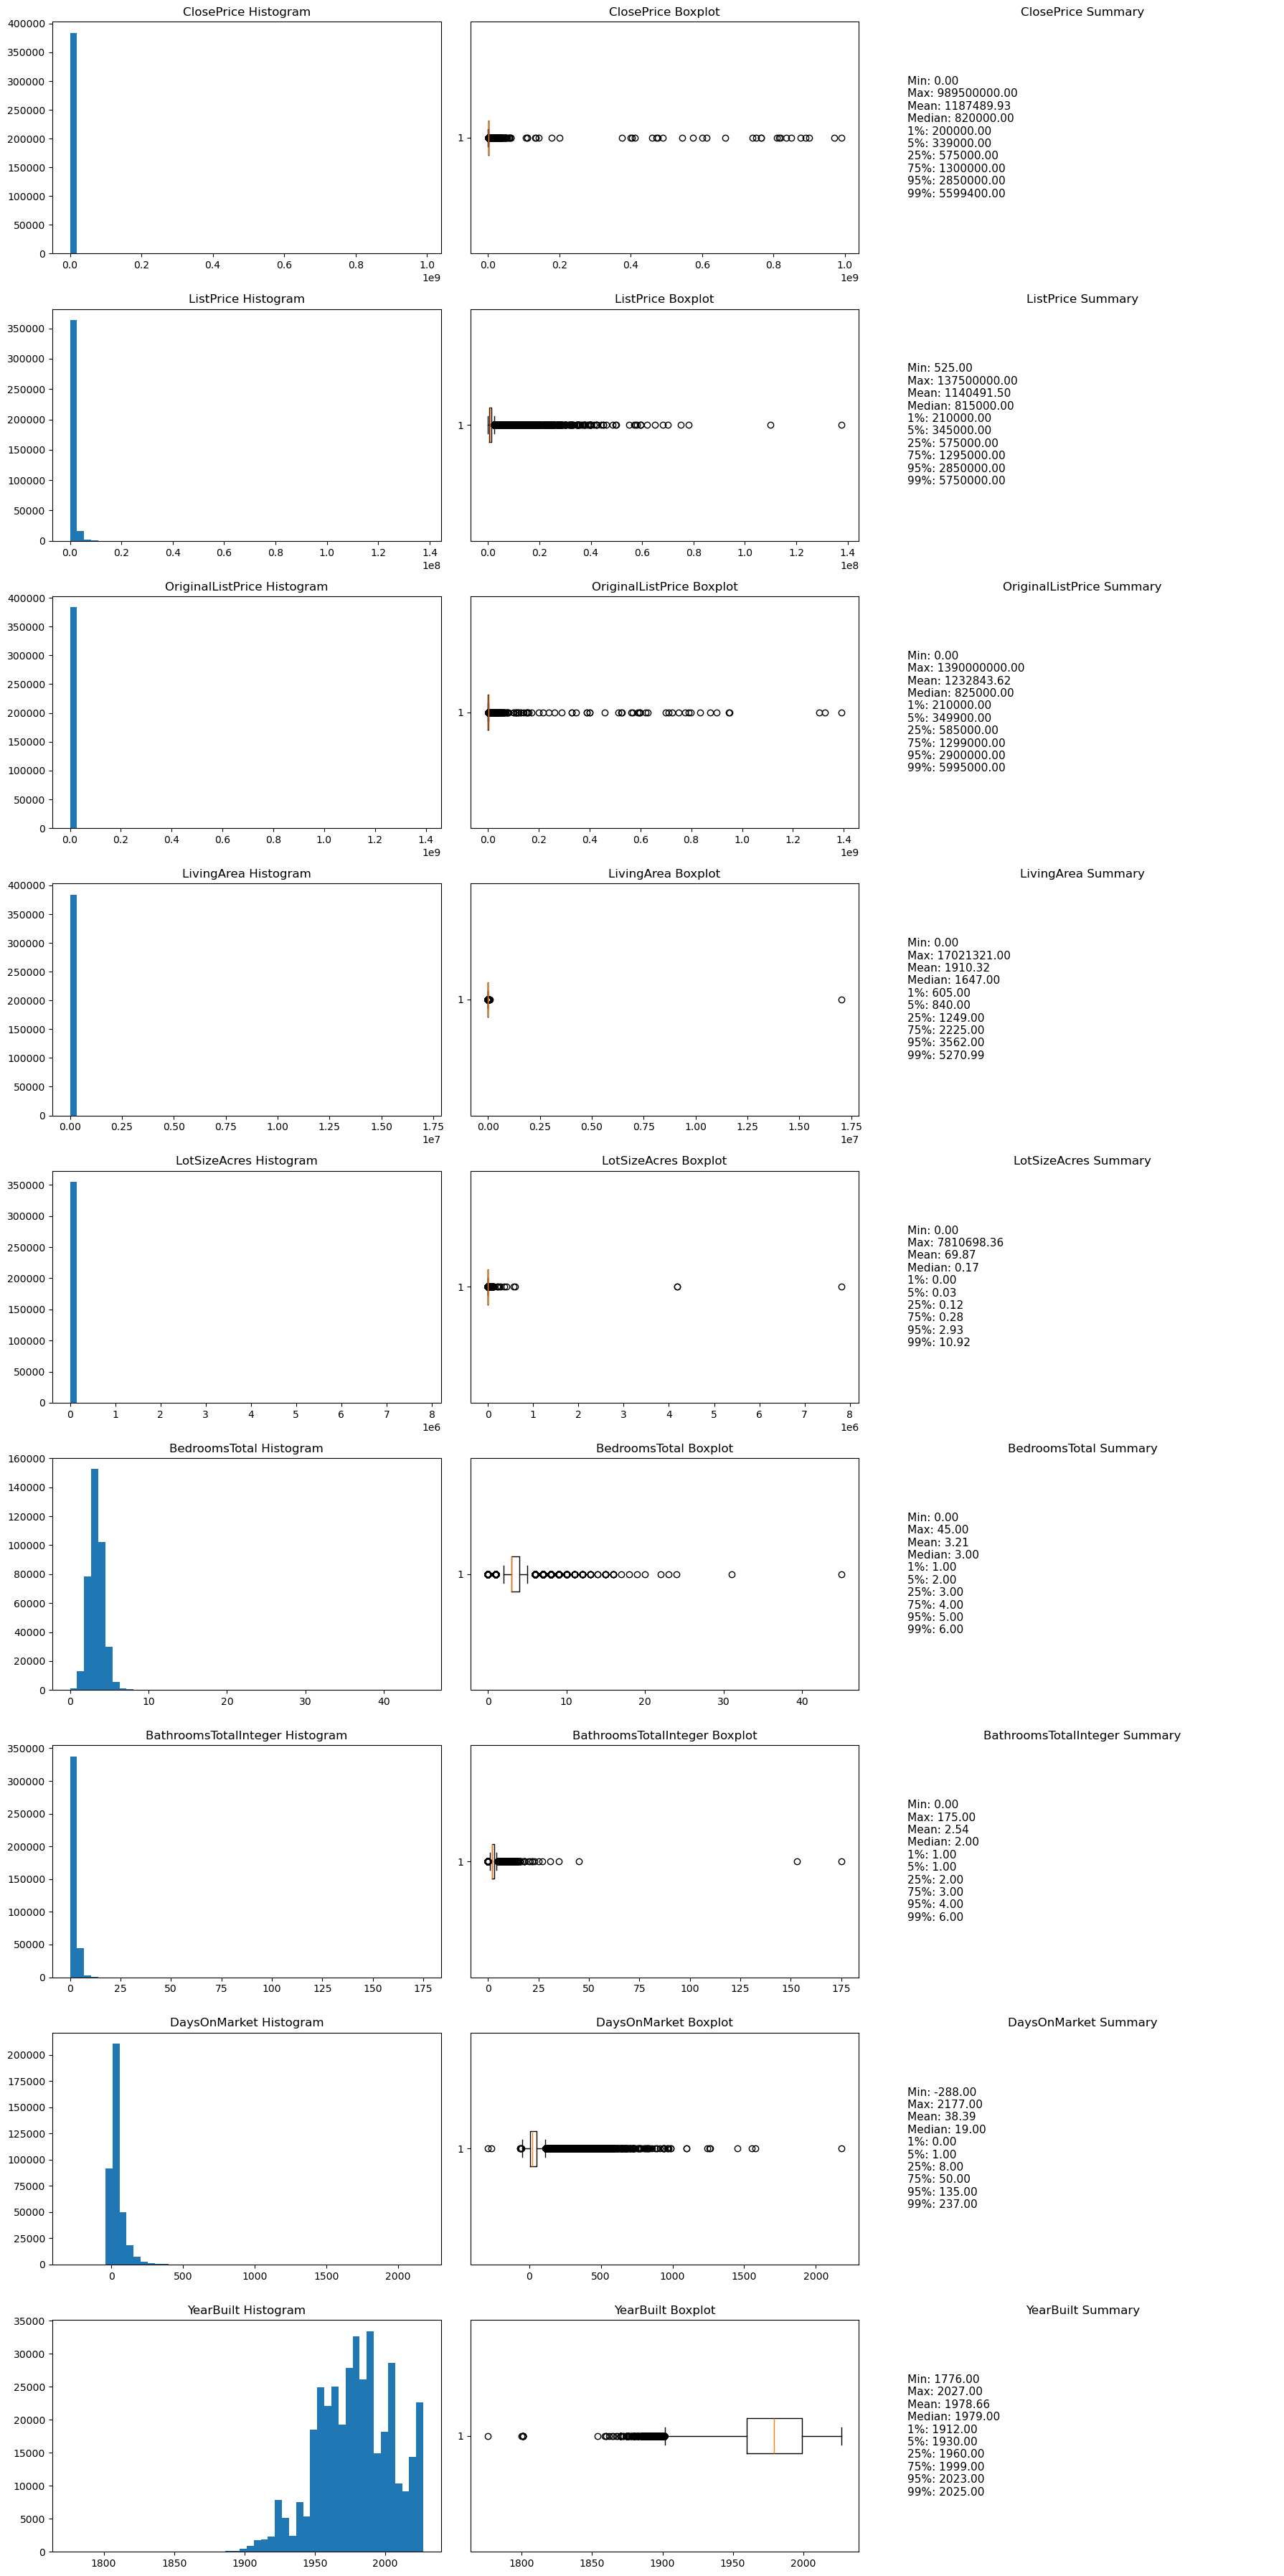

In [15]:
sold_plot = sold_clean.copy()

for col in numeric_fields:
    sold_plot[col] = pd.to_numeric(sold_plot[col], errors="coerce")

percentile_summary = sold_plot[numeric_fields].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

percentile_summary["median"] = percentile_summary["50%"]

fig, axes = plt.subplots(9, 3, figsize=(18, 36))

for i, col in enumerate(numeric_fields):
    data = sold_plot[col].dropna()

    axes[i, 0].hist(data, bins=50)
    axes[i, 0].set_title(f"{col} Histogram")

    axes[i, 1].boxplot(data, vert=False)
    axes[i, 1].set_title(f"{col} Boxplot")

    s = percentile_summary.loc[col]

    text = (
        f"Min: {s['min']:.2f}\n"
        f"Max: {s['max']:.2f}\n"
        f"Mean: {s['mean']:.2f}\n"
        f"Median: {s['median']:.2f}\n"
        f"1%: {s['1%']:.2f}\n"
        f"5%: {s['5%']:.2f}\n"
        f"25%: {s['25%']:.2f}\n"
        f"75%: {s['75%']:.2f}\n"
        f"95%: {s['95%']:.2f}\n"
        f"99%: {s['99%']:.2f}"
    )

    axes[i, 2].axis("off")
    axes[i, 2].text(0.05, 0.5, text, fontsize=11, va="center")
    axes[i, 2].set_title(f"{col} Summary")

plt.tight_layout()
plt.show()

#### Listing Datas

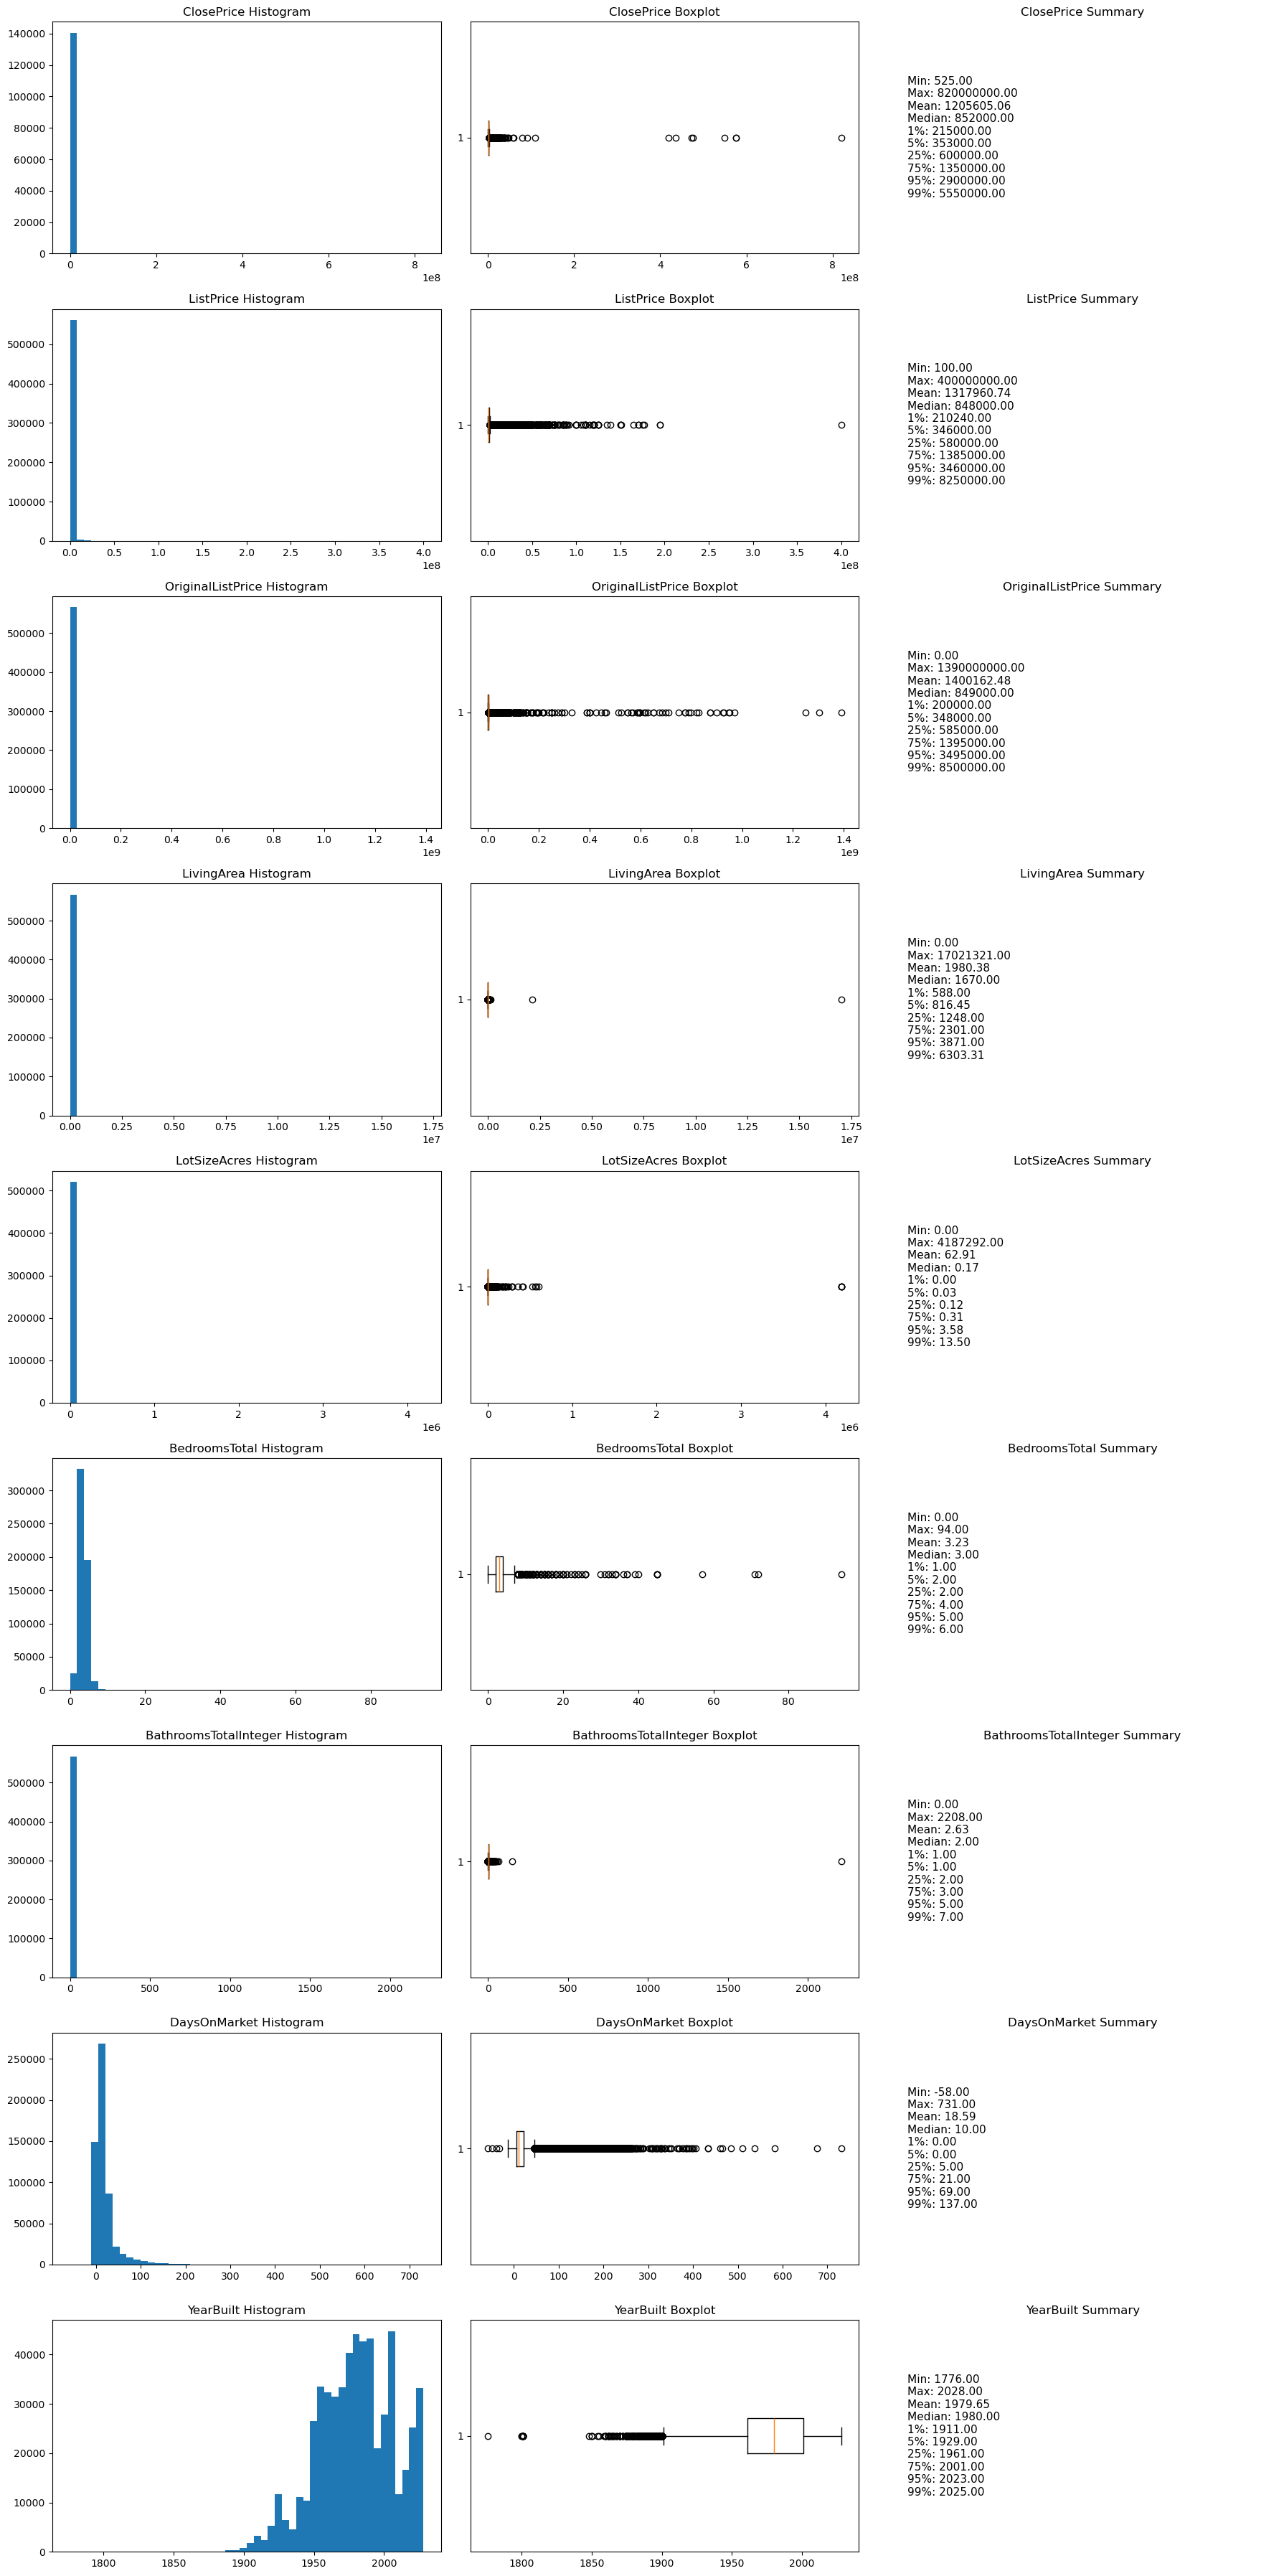

In [16]:
listing_plot = listing_clean.copy()

for col in numeric_fields:
    listing_plot[col] = pd.to_numeric(listing_plot[col], errors="coerce")

percentile_summary = listing_plot[numeric_fields].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

percentile_summary["median"] = percentile_summary["50%"]

fig, axes = plt.subplots(9, 3, figsize=(18, 36))

for i, col in enumerate(numeric_fields):
    data = listing_plot[col].dropna()

    axes[i, 0].hist(data, bins=50)
    axes[i, 0].set_title(f"{col} Histogram")

    axes[i, 1].boxplot(data, vert=False)
    axes[i, 1].set_title(f"{col} Boxplot")

    s = percentile_summary.loc[col]

    text = (
        f"Min: {s['min']:.2f}\n"
        f"Max: {s['max']:.2f}\n"
        f"Mean: {s['mean']:.2f}\n"
        f"Median: {s['median']:.2f}\n"
        f"1%: {s['1%']:.2f}\n"
        f"5%: {s['5%']:.2f}\n"
        f"25%: {s['25%']:.2f}\n"
        f"75%: {s['75%']:.2f}\n"
        f"95%: {s['95%']:.2f}\n"
        f"99%: {s['99%']:.2f}"
    )

    axes[i, 2].axis("off")
    axes[i, 2].text(0.05, 0.5, text, fontsize=11, va="center")
    axes[i, 2].set_title(f"{col} Summary")

plt.tight_layout()
plt.show()